In [ ]:
# IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# LOAD BOSTON DATASET
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

X = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y = raw_df.values[1::2, 2]

columns = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
           "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"]

X = pd.DataFrame(X, columns=columns)
y = pd.Series(y, name="MEDV")

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-708/1846049892.py:3: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [ ]:
print(X.shape)
print(X.info())
print(X.describe())

(506, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
dtypes: float64(13)
memory usage: 51.5 KB
None
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.32

In [ ]:
print(X.isnull().sum())
X.fillna(X.mean(), inplace=True)

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
dtype: int64


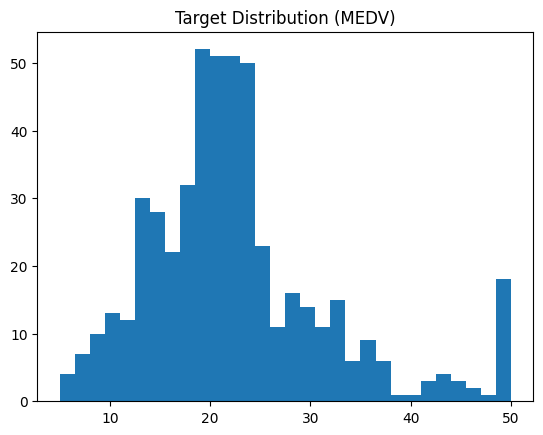

In [ ]:
plt.hist(y, bins=30)
plt.title("Target Distribution (MEDV)")
plt.show()
y = np.log1p(y)

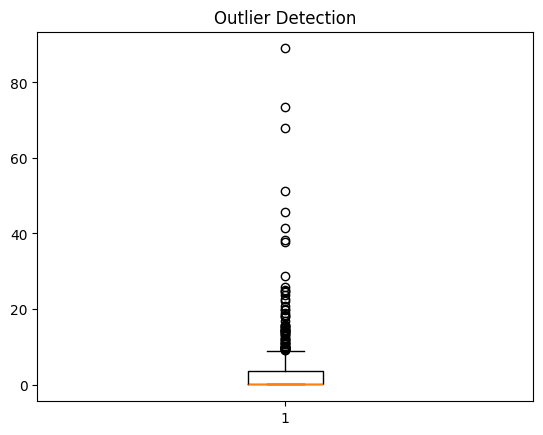

In [ ]:
plt.boxplot(X["CRIM"])
plt.title("Outlier Detection")
plt.show()

X = X[(X["CRIM"] < X["CRIM"].quantile(0.99))]

In [ ]:
# TRAIN TEST SPLIT

# Ensure y is aligned with the filtered X by re-indexing based on X's current index
y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# FEATURE SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Lasso , rigde and Elastic net MODELS
lasso = Lasso(alpha=0.1)
ridge = Ridge(alpha=1.0)
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)

lasso.fit(X_train_scaled, y_train)
ridge.fit(X_train_scaled, y_train)
elastic.fit(X_train_scaled, y_train)

ElasticNet(alpha=0.1)

In [ ]:
# PREDICTIONS
y_pred_lasso = lasso.predict(X_test_scaled)
y_pred_ridge = ridge.predict(X_test_scaled)
y_pred_elastic = elastic.predict(X_test_scaled)

In [ ]:
# PERFORMANCE METRICS
results = pd.DataFrame({
    "Model": ["Lasso (L1)", "Ridge (L2)", "Elastic Net"],
    "R2 Score": [
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_elastic)
    ],
    "MSE": [
        mean_squared_error(y_test, y_pred_lasso),
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_elastic)
    ]
})

print("\nModel Performance Comparison:\n")
print(results)


Model Performance Comparison:

         Model  R2 Score       MSE
0   Lasso (L1)  0.586836  0.056673
1   Ridge (L2)  0.688463  0.042733
2  Elastic Net  0.642390  0.049053


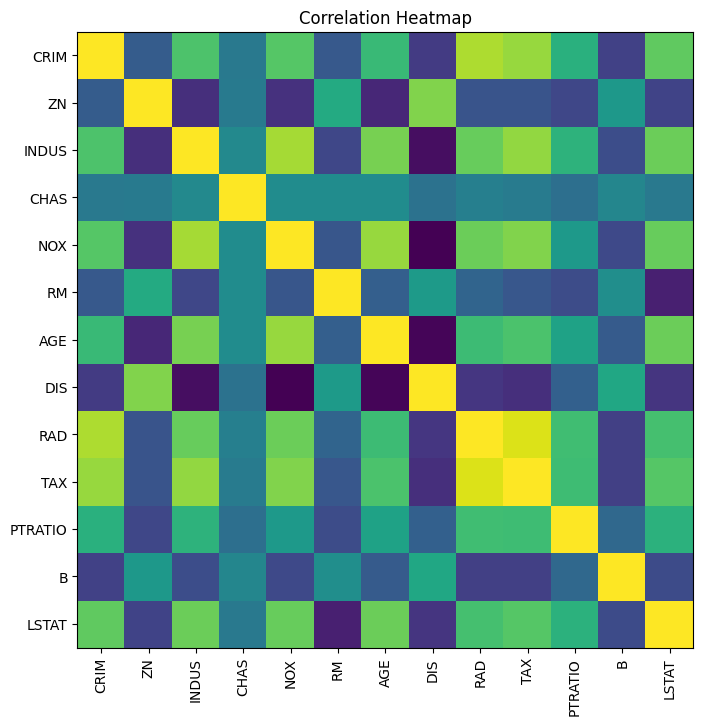

In [ ]:
# HEATMAP
plt.figure(figsize=(10,8))
corr = X.corr()
plt.imshow(corr)
plt.title("Correlation Heatmap")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

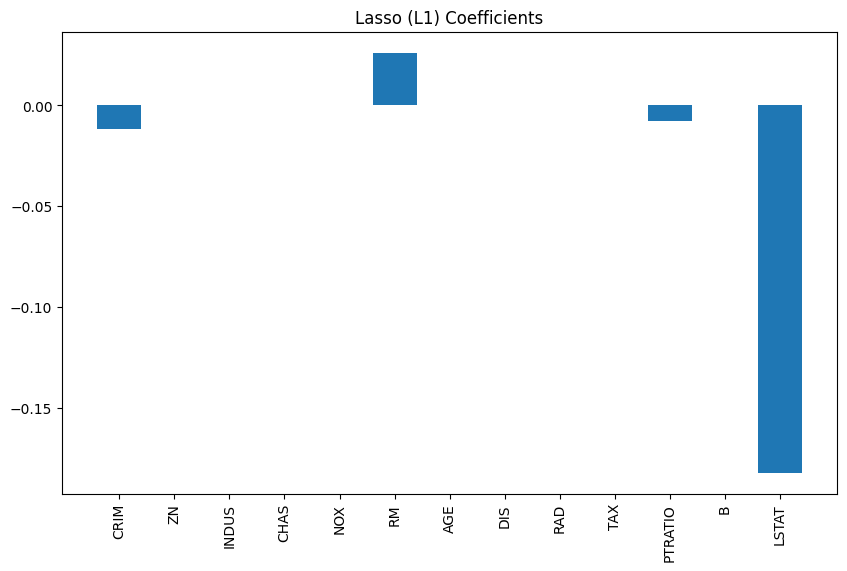

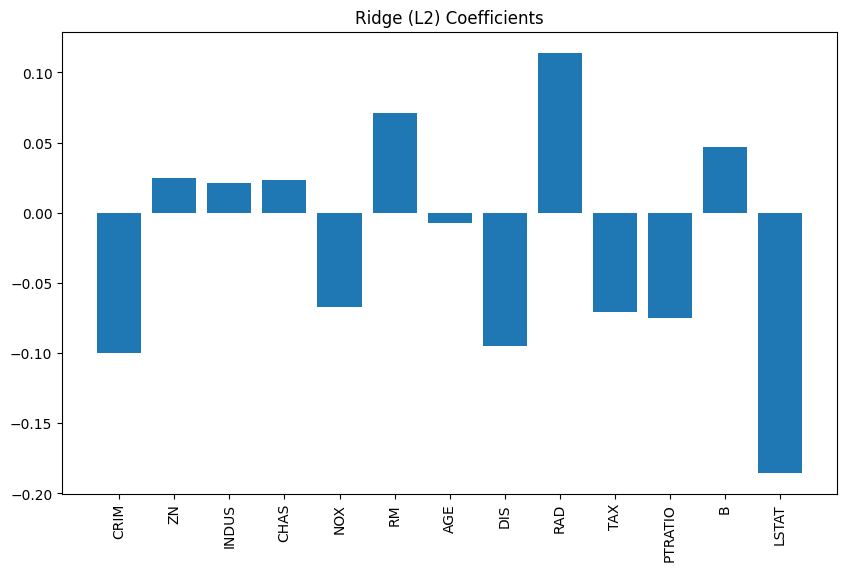

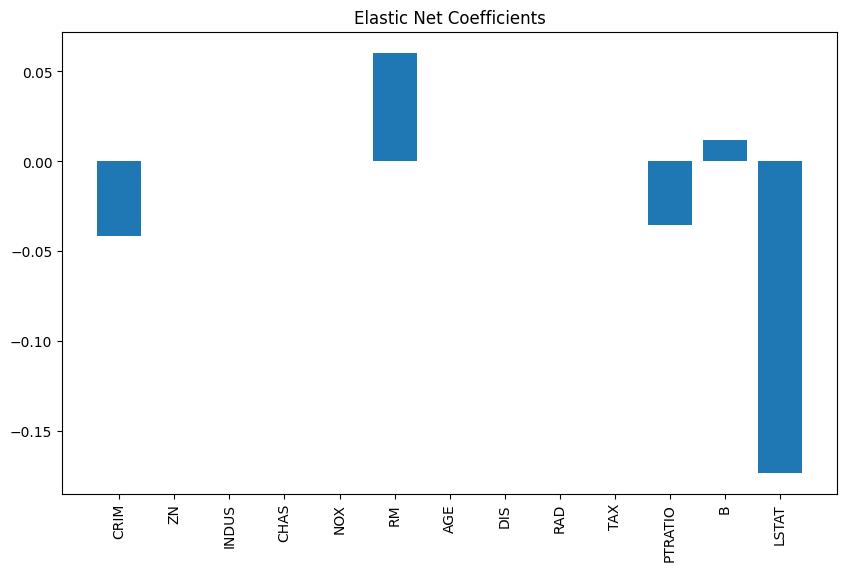

In [ ]:
# COEFFICIENT PLOTS
plt.figure(figsize=(10,6))
plt.bar(X.columns, lasso.coef_)
plt.title("Lasso (L1) Coefficients")
plt.xticks(rotation=90)
plt.show()
print("\n")

plt.figure(figsize=(10,6))
plt.bar(X.columns, ridge.coef_)
plt.title("Ridge (L2) Coefficients")
plt.xticks(rotation=90)
plt.show()
print("\n")

plt.figure(figsize=(10,6))
plt.bar(X.columns, elastic.coef_)
plt.title("Elastic Net Coefficients")
plt.xticks(rotation=90)
plt.show()

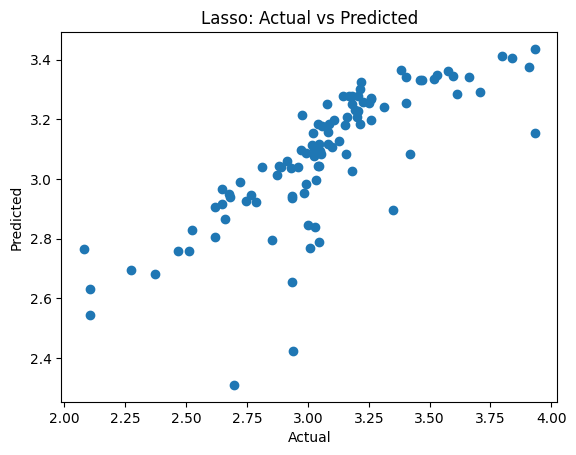

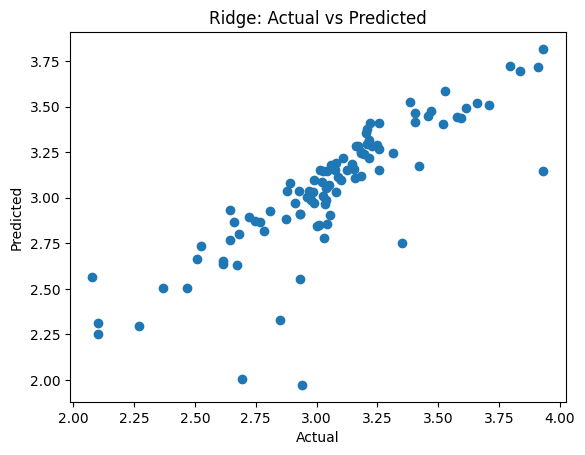

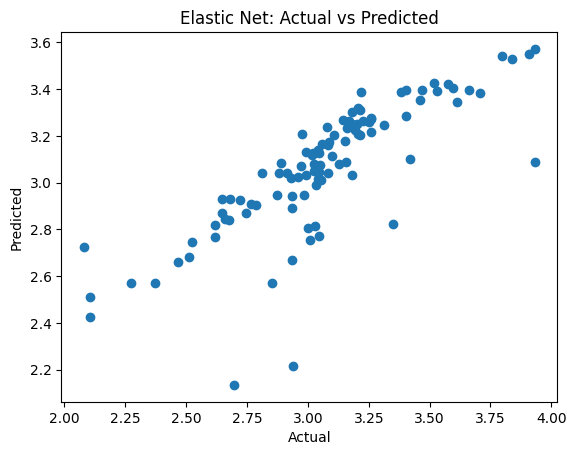

In [ ]:
# ACTUAL VS PREDICTED
plt.figure()
plt.scatter(y_test, y_pred_lasso)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Lasso: Actual vs Predicted")
plt.show()
print("\n")

plt.figure()
plt.scatter(y_test, y_pred_ridge)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Ridge: Actual vs Predicted")
plt.show()
print("\n")

plt.figure()
plt.scatter(y_test, y_pred_elastic)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Elastic Net: Actual vs Predicted")
plt.show()

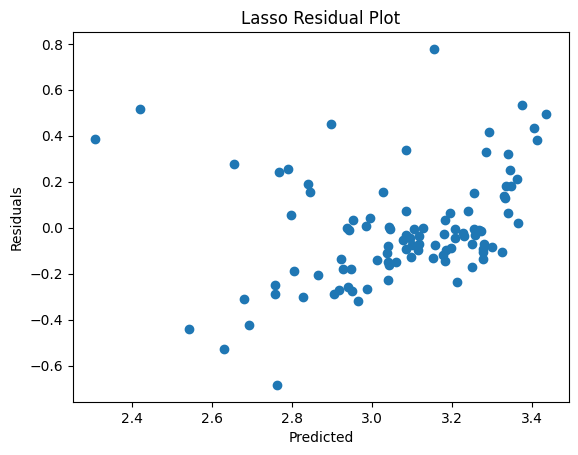

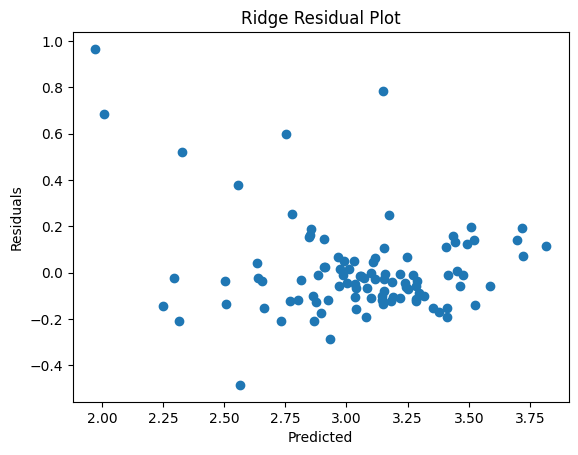

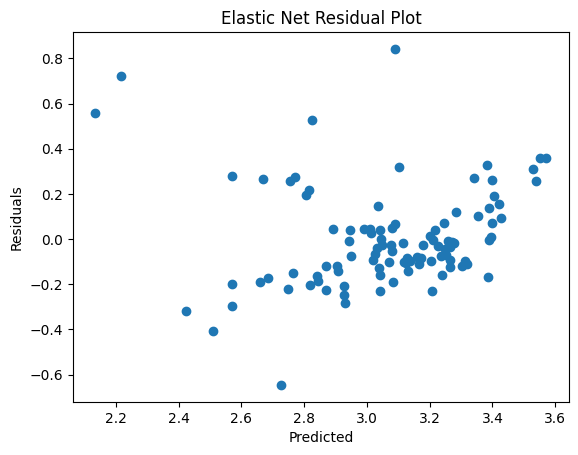

In [ ]:
# RESIDUAL PLOTS
plt.figure()
plt.scatter(y_pred_lasso, y_test - y_pred_lasso)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Lasso Residual Plot")
plt.show()

plt.figure()
plt.scatter(y_pred_ridge, y_test - y_pred_ridge)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Ridge Residual Plot")
plt.show()

plt.figure()
plt.scatter(y_pred_elastic, y_test - y_pred_elastic)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Elastic Net Residual Plot")
plt.show()


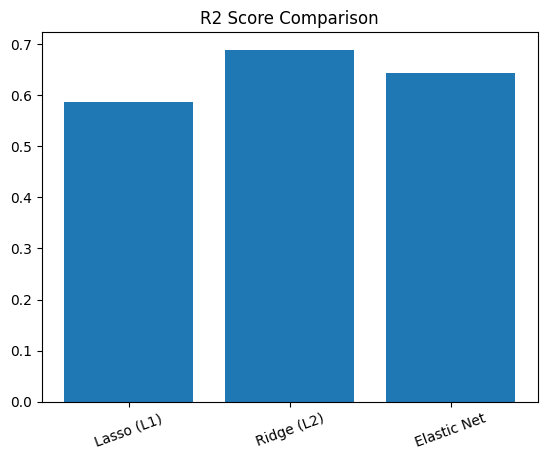

In [ ]:
# R2 COMPARISON BAR GRAPH
plt.figure()
plt.bar(results["Model"], results["R2 Score"])
plt.title("R2 Score Comparison")
plt.xticks(rotation=20)
plt.show()

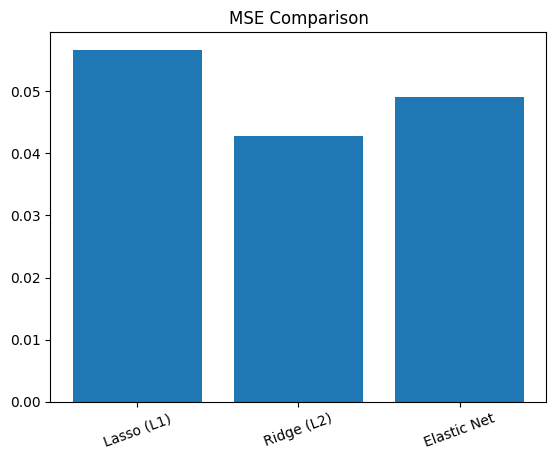

In [ ]:
# MSE COMPARISON BAR GRAPH
plt.figure()
plt.bar(results["Model"], results["MSE"])
plt.title("MSE Comparison")
plt.xticks(rotation=20)
plt.show()

In [ ]:
# BEST MODEL
best_model = results.loc[results["R2 Score"].idxmax()]
print("\nBest Performing Model Based on R2 Score:")
print(best_model["Model"])


Best Performing Model Based on R2 Score:
Ridge (L2)
